In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment_df = pd.read_csv('../../data/reviews_with_sentiment.csv')

theme_df = pd.read_csv('../../data/final_thematic_analysis.csv')

In [3]:
df = sentiment_df.merge(
    theme_df[['review_id', 'identified_theme']],
    on='review_id',
    how='left'
)

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,review_id,identified_theme
0,thanks for you 😘,5,2026-05-15,CBE,Google Play,positive,0.999622,1,Other
1,it's okay,4,2026-05-15,CBE,Google Play,positive,0.999828,2,Other
2,It's not allowing me to transfer money.,2,2026-05-15,CBE,Google Play,negative,0.996865,3,Transaction Performance
3,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play,negative,0.999691,4,Other
4,wow,4,2026-05-14,CBE,Google Play,positive,0.999592,5,Other


In [4]:
print(df.columns)
print(df.shape)

Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score', 'review_id', 'identified_theme'],
      dtype='str')
(1135, 9)


In [5]:
df['sentiment_label'].value_counts()

sentiment_label
positive    576
negative    559
Name: count, dtype: int64

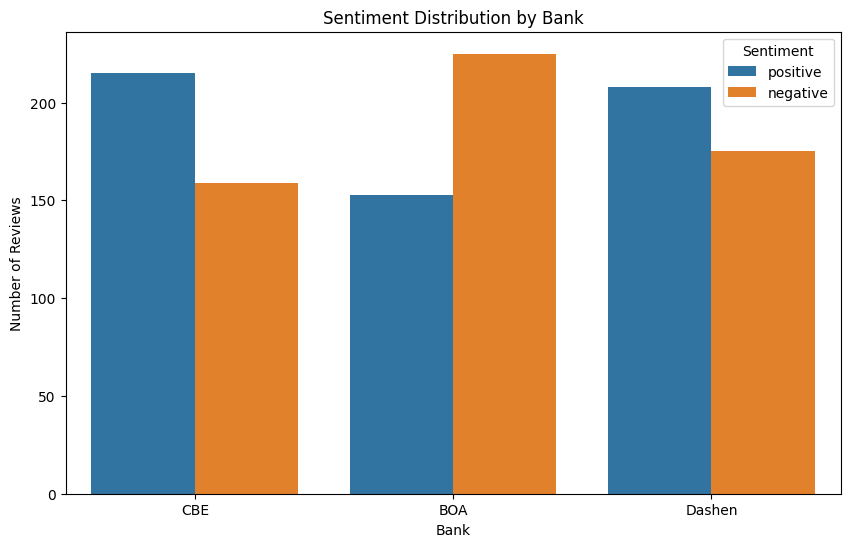

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')

plt.legend(title='Sentiment')

plt.savefig('../visuals/sentiment_distribution.png')
plt.show()

## Sentiment Distribution Analysis

The sentiment distribution analysis reveals how customer satisfaction differs across the three fintech banking applications. Positive reviews dominate the dataset overall, suggesting that many users are satisfied with the mobile banking experience. However, the distribution of negative reviews varies across banks, indicating differences in customer pain points and operational reliability.

Banks with a larger proportion of negative sentiment may be experiencing recurring issues related to transaction reliability, login failures, app crashes, or customer support responsiveness. Conversely, banks with stronger positive sentiment appear to provide more stable digital banking experiences and higher perceived service quality.

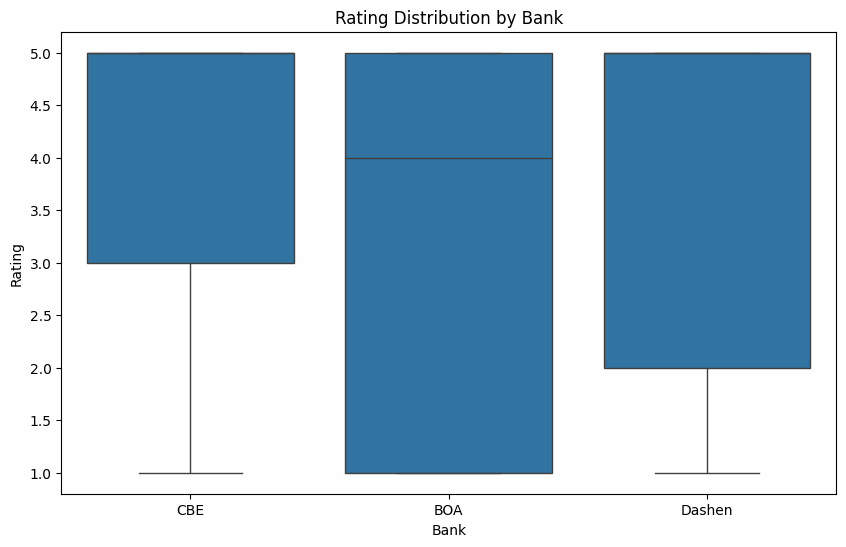

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bank',
    y='rating'
)

plt.title('Rating Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Rating')

plt.savefig('../visuals/sentiment_distribution.png')
plt.show()

## Rating Distribution Analysis

The rating distribution highlights differences in customer satisfaction consistency among the banks. Banks with tighter rating distributions and higher medians demonstrate more stable customer experiences, while wider distributions indicate inconsistent service quality.

Lower ratings are often associated with operational issues such as transaction delays, OTP failures, login problems, or poor customer support experiences. The visualization provides a quantitative overview of how users evaluate each banking platform overall.

In [8]:
df['identified_theme'].value_counts().head(10)

identified_theme
Other                      963
Transaction Performance     63
Customer Support            45
UI & Design                 30
Account Access Issues       22
Feature Requests            12
Name: count, dtype: int64

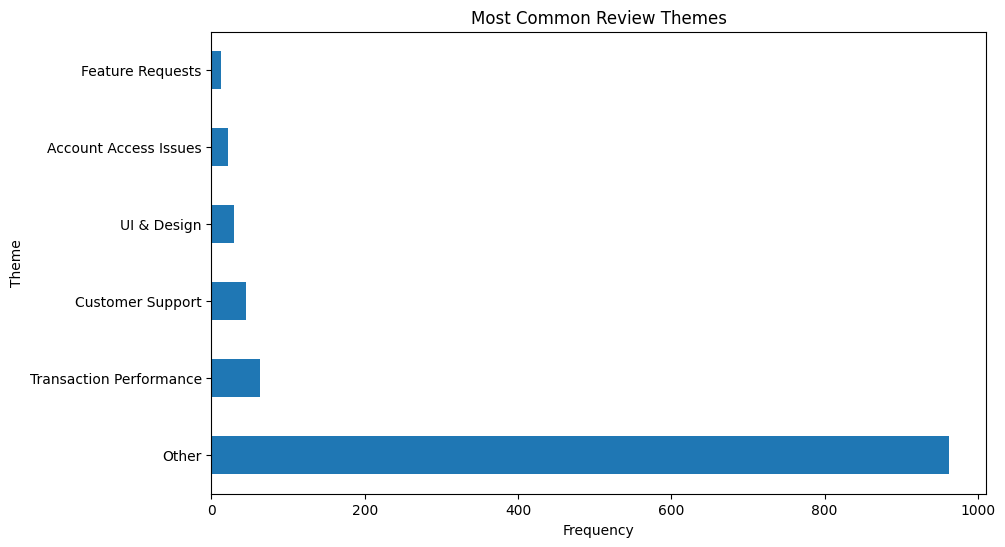

In [15]:
top_themes = df['identified_theme'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_themes.plot(kind='barh')

plt.title('Most Common Review Themes')
plt.xlabel('Frequency')
plt.ylabel('Theme')

plt.savefig('../visuals/sentiment_distribution.png')
plt.show()

## Thematic Analysis

The thematic analysis identifies the most frequently discussed issues and experiences within customer reviews. Transaction-related issues emerged as one of the most dominant themes, indicating that customers place high importance on reliability and speed when performing financial operations.

Themes related to account access, app usability, and customer support also appeared frequently, demonstrating that fintech user satisfaction extends beyond core banking functionality to include user experience and operational stability.

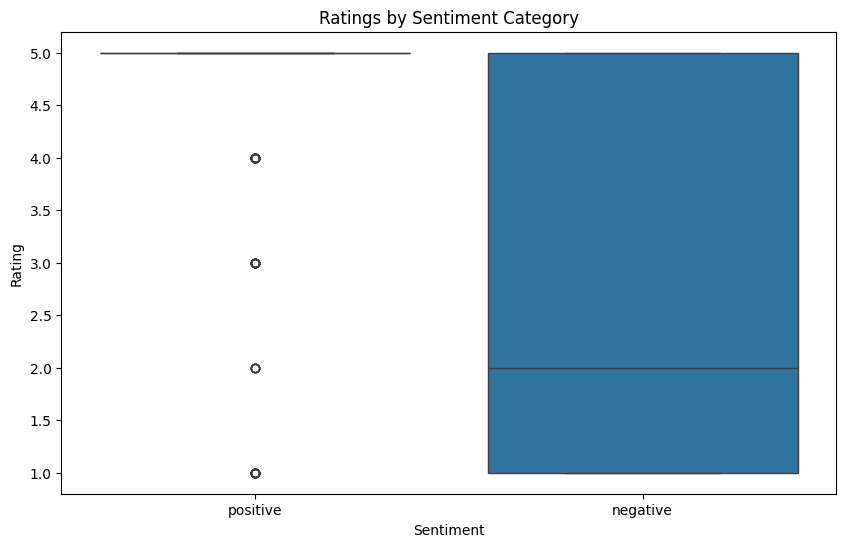

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='sentiment_label',
    y='rating'
)

plt.title('Ratings by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Rating')

plt.savefig('../visuals/sentiment_distribution.png')
plt.show()

In [11]:
positive_reviews = df[df['sentiment_label'] == 'positive']

positive_reviews['identified_theme'].value_counts().head(5)

identified_theme
Other                      513
Customer Support            31
UI & Design                 16
Transaction Performance      7
Feature Requests             6
Name: count, dtype: int64

In [12]:
negative_reviews = df[df['sentiment_label'] == 'negative']

negative_reviews['identified_theme'].value_counts().head(5)

identified_theme
Other                      450
Transaction Performance     56
Account Access Issues       19
Customer Support            14
UI & Design                 14
Name: count, dtype: int64

In [13]:
df[df['bank'] == 'CBE']
df[df['bank'] == 'BOA']
df[df['bank'] == 'Dashen']

,review,rating,date,bank,source,sentiment_label,sentiment_score,review_id,identified_theme
752,best app so far. thank you,5,2026-05-15,Dashen,Google Play,positive,0.999848,753,Other
753,Very Annoying App i tried to open virtual bank...,1,2026-05-14,Dashen,Google Play,negative,0.999444,754,UI & Design
754,good app but it was doesnt work other bank tra...,5,2026-05-14,Dashen,Google Play,negative,0.996920,755,Transaction Performance
755,"i swear to god , By using this app, I won a Sa...",5,2026-05-14,Dashen,Google Play,positive,0.999208,756,Other
756,good and easier to used,5,2026-05-14,Dashen,Google Play,positive,0.999848,757,Other
...,...,...,...,...,...,...,...,...,...
1130,"Great app, unfortunately I struggle to use it ...",1,2025-08-15,Dashen,Google Play,negative,0.995208,1131,Other
1131,It was easy enough before. but now it won't ev...,3,2025-08-14,Dashen,Google Play,negative,0.999611,1132,Customer Support
1132,There are plenty of features missed e. g elect...,2,2025-08-14,Dashen,Google Play,negative,0.999018,1133,Feature Requests
1133,የሶፍትዌሩ ለአጠቃቀም ምቹና ቀላል መሆኑ ተመራጭ ያደርገዋል,5,2025-08-14,Dashen,Google Play,negative,0.920041,1134,Other
